In [1]:
import zipfile
import os

# Path to your ZIP file
zip_path = r'C:/Users/HP/Downloads/balanced_labeled_photos.zip'
extract_path = r'yelp_photos'  # where to extract

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check folders
print("Extracted folders:", os.listdir(extract_path))


Extracted folders: ['balanced_labeled_photos', 'Dataset_User_Agreement.pdf', 'photos', 'photos.json']


In [3]:
photos_path = os.path.join(data_root, "photos")
photo_files = os.listdir(photos_path)

print(f"Total photos: {len(photo_files)}")
print("First 10 photo filenames:", photo_files[:10])


NameError: name 'data_root' is not defined

In [5]:
with open("photo_list.txt", "w") as f:
    for name in photo_files:
        f.write(name + "\n")

print("Filenames written to photo_list.txt")


Filenames written to photo_list.txt


In [6]:
import os

data_root = "yelp_photos"
folder = "balanced_labeled_photos"
full_path = os.path.join(data_root, folder)

# List only first 10 files from each class folder
for class_folder in os.listdir(full_path):
    class_path = os.path.join(full_path, class_folder)
    files = os.listdir(class_path)
    print(f"Class '{class_folder}' has {len(files)} images. Here are 10 samples:")
    print(files[:10])


Class 'drink' has 15670 images. Here are 10 samples:
['--puCF1Lauwb3k6vrVVvfQ.jpg', '--y-d0b4_JQeKv7Yz39_Kw.jpg', '-0-Sor-tVeKH_KXSWI8SMw.jpg', '-03jEudW-0CXZhRhY9j3cg.jpg', '-07rvFvU6UOTuSEGa6HR9A.jpg', '-1h8RaVNoRDMJ1TuR--UPw.jpg', '-1wBDCpkQRt0X4QqhO5uMw.jpg', '-26yvqotk0rqT6OFGXTaOw.jpg', '-3-BFGlvZS2GA1yxdqm3Mw.jpg', '-32lR19VYAZQok6Z8tN_9w.jpg']
Class 'food' has 20000 images. Here are 10 samples:
['--3JQ4MlO-jHT9xbo7liug.jpg', '--9cH8_rrskfmYvONaJpgQ.jpg', '--j4xVIdIlYpOmZbs7iszg.jpg', '--wxyCFpNg13pVl00xvlXg.jpg', '--zScnI03KioBVMtcOK6oQ.jpg', '-0A6_xM5K-YK8wwnGgBpEQ.jpg', '-0fa0mOVKrJW90MFFxVImg.jpg', '-0l6FrIjTVo8x92V0XBTZA.jpg', '-0SNYNp7RKMuGqSc_Rycqg.jpg', '-10Ge63S6TdapDZV5ZGJLw.jpg']
Class 'inside' has 20000 images. Here are 10 samples:
['--4DfhW2sJvjeC90KEDX3g.jpg', '--7SiWWk_OHbdmcU4pNDQw.jpg', '--AU_cPMgrWSPluP1v8n_Q.jpg', '--dacvi4Y_8ACp-10nafMA.jpg', '--e8vgtonVwPXG3n6lfBLA.jpg', '--gjH9oA92f7OuTSovXjCg.jpg', '--kP__1IcWsQE0ycWKT0bg.jpg', '--WioehVQHeKzop8t3_8Bw.jpg'

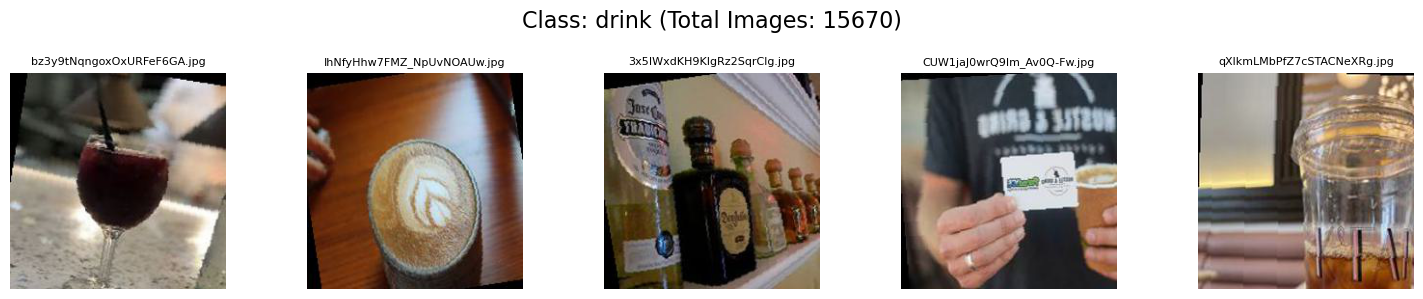

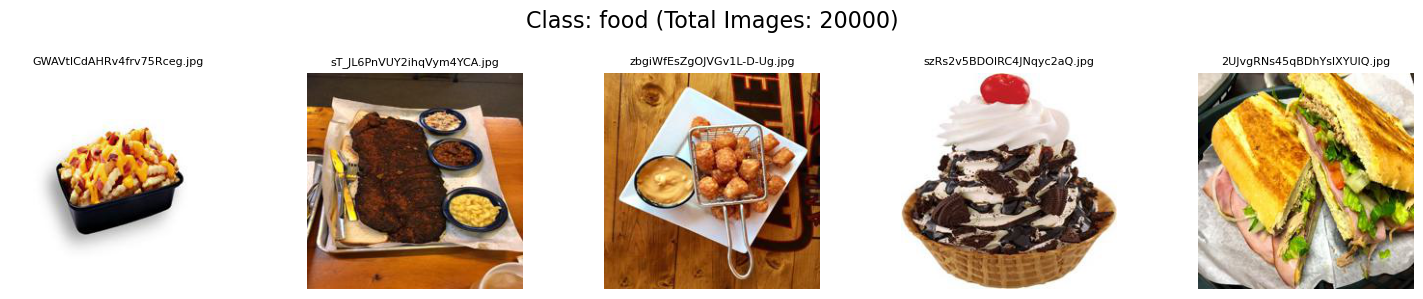

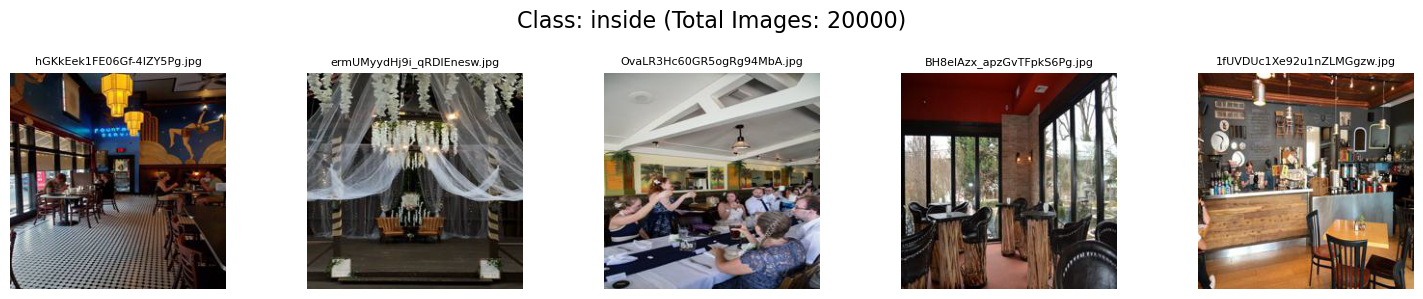

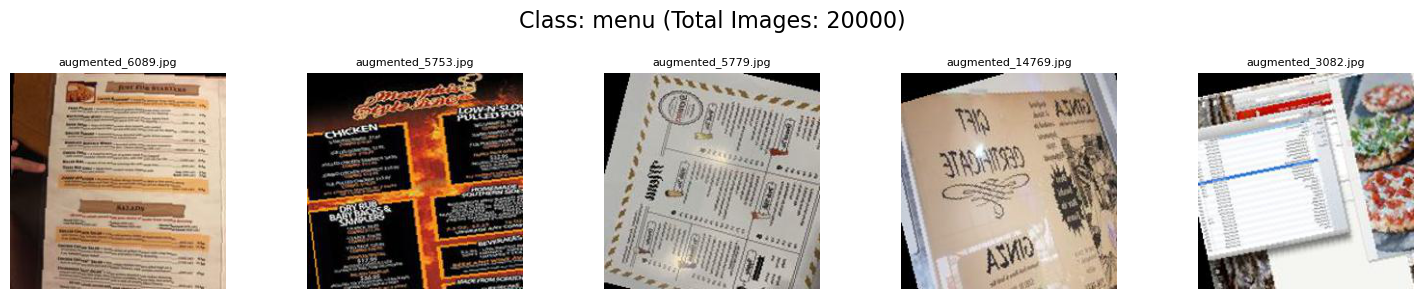

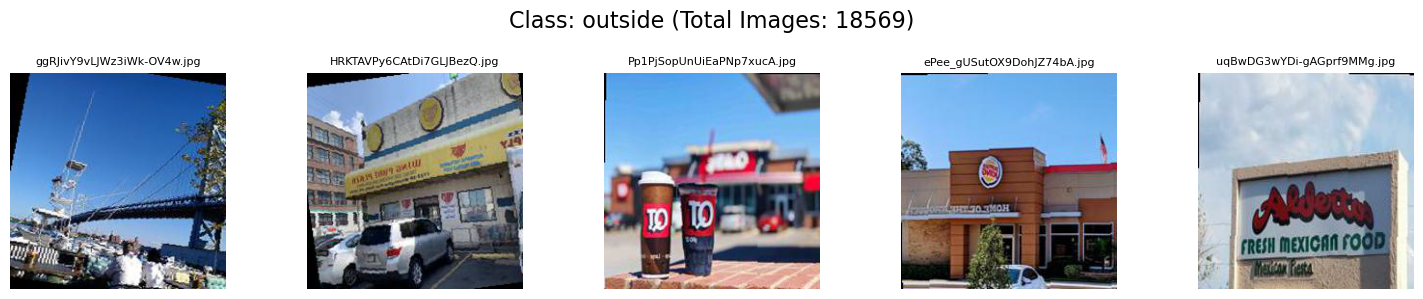

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

data_root = "yelp_photos"
folder = "balanced_labeled_photos"
full_path = os.path.join(data_root, folder)

# Set how many images you want to display per class
num_samples = 5

# Loop through each class folder
for class_folder in os.listdir(full_path):
    class_path = os.path.join(full_path, class_folder)
    image_files = os.listdir(class_path)
    
    # Randomly sample images
    if len(image_files) >= num_samples:
        sample_images = random.sample(image_files, num_samples)
    else:
        sample_images = image_files  # in case there are fewer than num_samples

    # Create a new figure for each class
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_folder} (Total Images: {len(image_files)})", fontsize=16)
    
    # Loop through the sample images and display them
    for i, img_file in enumerate(sample_images):
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            continue
        
        ax = plt.subplot(1, num_samples, i + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(img_file, fontsize=8)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [8]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

def load_and_preprocess_images(image_folder, image_filenames):
    images = []
    for fname in image_filenames:
        img_path = os.path.join(image_folder, fname)
        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = preprocess_input(img_array)  # VGG16 preprocessing
            images.append(img_array)
        except Exception as e:
            print(f"Error loading {fname}: {e}")
    return np.array(images)


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "yelp_photos/balanced_labeled_photos"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 train-val split
)

# Training generator
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation generator
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 75392 images belonging to 5 classes.
Found 18847 images belonging to 5 classes.


In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [12]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG16 base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model (or fine-tune later)
for layer in base_model.layers:
    layer.trainable = False

# Add classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [14]:
import os

# Set path to a specific class folder (e.g., 'food')
folder_path = "yelp_photos/balanced_labeled_photos/food"

# List first 10 image filenames in that folder
image_files = os.listdir(folder_path)
print("Found", len(image_files), "images.")
print("Here are 10 example filenames:")
print(image_files[:10])


Found 20000 images.
Here are 10 example filenames:
['--3JQ4MlO-jHT9xbo7liug.jpg', '--9cH8_rrskfmYvONaJpgQ.jpg', '--j4xVIdIlYpOmZbs7iszg.jpg', '--wxyCFpNg13pVl00xvlXg.jpg', '--zScnI03KioBVMtcOK6oQ.jpg', '-0A6_xM5K-YK8wwnGgBpEQ.jpg', '-0fa0mOVKrJW90MFFxVImg.jpg', '-0l6FrIjTVo8x92V0XBTZA.jpg', '-0SNYNp7RKMuGqSc_Rycqg.jpg', '-10Ge63S6TdapDZV5ZGJLw.jpg']


In [15]:
img_path = "yelp_photos/balanced_labeled_photos/food/--3JQ4MlO-jHT9xbo7liug.jpg"


In [16]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path):
    # Load image resized to 224x224
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    # Preprocess for VGG16
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)
    return img_array

image_tensor = preprocess_image(img_path)

print("Image tensor shape:", image_tensor.shape)  # Should be (224, 224, 3)


Image tensor shape: (224, 224, 3)


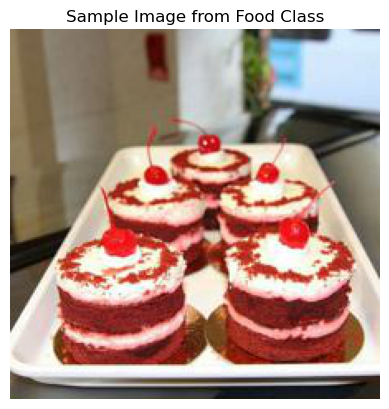

In [17]:
# VGG preprocessing changes pixel values, so show original image separately
original_img = load_img(img_path, target_size=(224, 224))

plt.imshow(original_img)
plt.title("Sample Image from Food Class")
plt.axis('off')
plt.show()


In [18]:
# Add batch dimension: (1, 224, 224, 3)
image_batch = np.expand_dims(image_tensor, axis=0)

# Now you can use image_batch as input to your VGG16-based model


In [19]:
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
print(class_to_idx)


{'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [20]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import tensorflow as tf

def preprocess_image(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)
    return img_array

image_list = []
label_list = []

data_root = "yelp_photos/balanced_labeled_photos"
classes = ['drink', 'food', 'inside', 'menu', 'outside']

for cls in classes:
    folder_path = os.path.join(data_root, cls)
    filenames = os.listdir(folder_path)[:20]  # Load first 20 images from each class
    
    for fname in filenames:
        img_path = os.path.join(folder_path, fname)
        image = preprocess_image(img_path)
        image_list.append(image)
        label_list.append(class_to_idx[cls])

# Convert to numpy arrays
X = np.array(image_list)
y = np.array(label_list)

print("Images shape:", X.shape)  # (number_of_images, 224, 224, 3)
print("Labels shape:", y.shape)  # (number_of_images,)


Images shape: (100, 224, 224, 3)
Labels shape: (100,)


In [21]:
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y, num_classes=5)
print("One-hot labels shape:", y_cat.shape)


One-hot labels shape: (100, 5)


In [22]:
history = model.fit(X, y_cat, epochs=5, batch_size=16, validation_split=0.2)


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.1464 - loss: 8.5204 - val_accuracy: 0.2500 - val_loss: 3.6445
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.1892 - loss: 6.5098 - val_accuracy: 0.1000 - val_loss: 4.9394
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1882 - loss: 6.6988 - val_accuracy: 0.0000e+00 - val_loss: 6.0099
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.3099 - loss: 4.9051 - val_accuracy: 0.0000e+00 - val_loss: 6.8436
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.2988 - loss: 4.3549 - val_accuracy: 0.0000e+00 - val_loss: 7.6925


In [24]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Load VGG16 base model without top layers
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model layers so they won't be trained initially
vgg_base.trainable = False

# 3. Image input and base output
image_input = vgg_base.input
x = vgg_base.output
x = GlobalAveragePooling2D()(x)

# 4. Metadata input (change shape to 0 if no metadata)
metadata_input = Input(shape=(10,), name="meta_input")

# 5. Combine image features with metadata
combined = Concatenate()([x, metadata_input])
combined = Dense(256, activation='relu')(combined)
combined = Dropout(0.3)(combined)
combined = Dense(128, activation='relu')(combined)
combined = Dropout(0.3)(combined)
output = Dense(5, activation='softmax')(combined)

# 6. Final model
model = Model(inputs=[image_input, metadata_input], outputs=output)

# 7. Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [25]:
# Without metadata input:
image_input = vgg_base.input
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=image_input, outputs=output)


In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [28]:
import tensorflow as tf

batch_size = 32
img_size = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "yelp_photos/balanced_labeled_photos",  # path to your image folders
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "yelp_photos/balanced_labeled_photos",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
)


Found 94239 files belonging to 5 classes.
Using 75392 files for training.
Found 94239 files belonging to 5 classes.
Using 18847 files for validation.


In [30]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',  # <-- change here
    metrics=['accuracy']
)


In [33]:
def one_hot_label(image, label):
    label = tf.one_hot(label, depth=5)
    return image, label

train_dataset = train_dataset.map(one_hot_label)
val_dataset = val_dataset.map(one_hot_label)


In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [38]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,       # or more epochs if you want
    verbose=1
)


Epoch 1/5
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7117 - loss: 1.5669

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import tensorflow as tf

# Step 1: Extract all true labels and predictions from val_dataset
true_labels = []
pred_probs = []

for images, labels in val_dataset:
    preds = model.predict(images)
    pred_probs.append(preds)
    true_labels.append(labels.numpy())

# Concatenate all batches
true_labels = np.concatenate(true_labels)
pred_probs = np.concatenate(pred_probs)

# If your labels are one-hot encoded, convert to class indices
if true_labels.ndim > 1 and true_labels.shape[1] > 1:
    true_classes = np.argmax(true_labels, axis=1)
else:
    true_classes = true_labels

pred_classes = np.argmax(pred_probs, axis=1)

# Step 2: Compute AUC (One-vs-Rest for multi-class)
auc = roc_auc_score(true_labels, pred_probs, multi_class='ovr')
print(f"AUC: {auc:.4f}")

# Step 3: Compute Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
print("Confusion Matrix:")
print(cm)

# Optional: Classification Report (precision, recall, f1)
print("\nClassification Report:")
print(classification_report(true_classes, pred_classes))


In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")


In [ ]:
model.save("my_vgg16_finetuned_model.h5")


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

img_path = "path_to_new_image.jpg"
img_tensor = load_and_preprocess_image(img_path)
pred_probs = model.predict(img_tensor)
predicted_class = np.argmax(pred_probs)
print(f"Predicted class: {predicted_class}")


In [ ]:
#FIne tuning 

In [ ]:
# 1. Unfreeze some of the last layers of VGG16 base
vgg_base.trainable = True

# Let's say we freeze all layers except the last 4 convolutional blocks
for layer in vgg_base.layers[:-4]:
    layer.trainable = False

# 2. Compile the model with a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Lower lr
    loss='sparse_categorical_crossentropy',  # Use sparse labels or categorical_crossentropy accordingly
    metrics=['accuracy']
)

# 3. Continue training (fine-tuning)
history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,  # or more, depending on your dataset
    verbose=1
)


In [ ]:
# Evaluate on validation data
val_loss, val_acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")


In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss')

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Accuracy')

    plt.show()

plot_history(history_finetune)


In [ ]:
model.save("my_vgg16_finetuned_model.h5")


In [ ]:
predictions = model.predict(new_images_dataset)
predicted_classes = tf.argmax(predictions, axis=1)


In [ ]:
best_hps = tuner.get_best_hyperparameters(1)[0]
model = tuner.hypermodel.build(best_hps)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)


In [ ]:
#first promt:How cnn model work and give me code for it 
#last promt: how can I manage overfitting